In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import sputnik_stages, sputnik, titan2_stages
from mad.configs.planets import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, SatelliteConfig, SputnikConfig
from mad.guidances import NoGuidance, LEOInsertionGuidance
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

In [4]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in sputnik_stages]

missile_guidance = LEOInsertionGuidance(planet=earth, 
                                        perigee_altitude_m = 200_000,
                                        apogee_altitude_m=400_000,
                                        # target=target,
                                        min_turn_altitude_m=200,
                                        turn_end_altitude_m=180_000,)


payload_cfg = SputnikConfig(**sputnik)

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payloads=[payload_cfg], 
                                     payload_separation_interval=5.0)
semyorka = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Semyorka")

semyorka


BallisticMissile Semyorka, active.
Stages: Bloc_BVGD, Bloc_A.
Available deltaV: 10459.25 m/s.
Guidance: LEOInsertionGuidance.
Payloads: Sputnik.

In [5]:
dt = 1.0
max_time = 15_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[semyorka],
)

df = sim.results

18:36:05 | INFO     | Simulation   | Starting simulation.
18:36:05 | INFO     | Missile      | Bloc_BVGD ran out of propellant at 59.00.
18:36:05 | INFO     | Missile      | Semyorka - Bloc_BVGD separated at 59.00.
18:36:05 | INFO     | Simulation   | New objects spawned this step: ['Bloc_BVGD']
18:36:05 | INFO     | Guidance     | Orbit insertion achieved at altitude 204.7 km, v_horiz = 7845.3 m/s (target 7846.4 m/s).
18:36:05 | INFO     | Satellite    | Sputnik released into orbit -- Beep Beep!
18:36:05 | INFO     | Missile      | Semyorka released payload Sputnik_1 at 331.00.
18:36:05 | INFO     | Missile      | Semyorka has released all payloads at 331.00. Stages deactivated.
18:36:05 | INFO     | Missile      | Semyorka - Bloc_A separated at 331.00.
18:36:05 | INFO     | Missile      | Semyorka inactivated at 331.00.
18:36:05 | INFO     | Simulation   | New objects spawned this step: ['Sputnik_1', 'Bloc_A']
18:36:05 | INFO     | Projectile   | Bloc_BVGD landed on the ground!
18:36

In [6]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

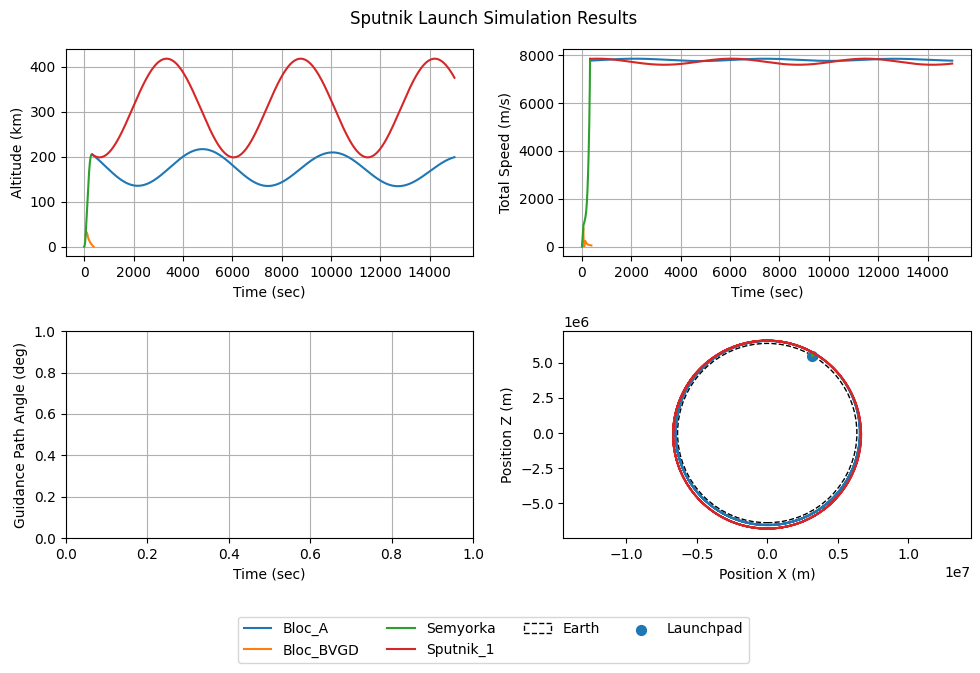

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad], ax=ax[3], display="planet")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Sputnik Launch Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)
